In [1]:
import torch
import torch.nn as nn # Layers and all neural network stuff
import torch.nn.functional as F # Related to the activation functions
import torch.optim as optim # These are the optimizers implemented in torch
from torch.autograd import grad # To compute derivatives via automatic differentiation

from pydoe import lhs # Latin Hypercube Sampling
import numpy as np

from m3_optimizer_pytorch import M3Optimizer

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [3]:
torch.set_float32_matmul_precision('highest') # Set this to 'highest' because our
                                              # specific workload is highly sensitive to numerical accuracy

In [4]:
# Setting a seed for replicate data
torch.manual_seed(1234)
np.random.seed(1234)

# To create layers in PyTorch
class layer(nn.Module):
    def __init__(self, n_in, n_out, activation):
        super().__init__()
        self.layer = nn.Linear(n_in, n_out)
        self.activation = activation

    def forward(self, x):
        x = self.layer(x)
        if self.activation:
            x = self.activation(x)
        return x

# To create a dense neural network
# Recall that the activation function has to be Tanh since it is differentiable in all points
class DNN(nn.Module):
    def __init__(self, dim_in, dim_out, n_layer, n_node, ub, lb, activation=nn.Tanh()):
        super().__init__()
        self.net = nn.ModuleList() # To being able to set a variable number of layers (since we'll use a loop)
        self.net.append(layer(dim_in, n_node, activation)) # Dim corresponding to the input size and n_node
                                                           # corresponds to the units for the first layer
        for _ in range(n_layer):
            self.net.append(layer(n_node, n_node, activation)) # All hidden layers have the same quantity of units
        self.net.append(layer(n_node, dim_out, activation=None)) # Last linear layer, we set the output dim
        self.ub = torch.tensor(ub, dtype = torch.float).to(device) 
        self.lb = torch.tensor(lb, dtype = torch.float).to(device)
        self.net.apply(weights_init)  

    def forward(self, x):
        x = (x - self.lb) / (self.ub - self.lb)  # Min-max scaling
        out = x
        for layer in self.net:
            out = layer(out)
        return out

def weights_init(m): # xavier initialization
    if isinstance(m, nn.Linear):
        torch.nn.init.xavier_uniform_(m.weight.data)
        torch.nn.init.zeros_(m.bias.data)

In [5]:
import matplotlib.pyplot as plt

def plotLoss(losses_dict, path, info=["IC", "BC", "PDE"]):
    fig, axes = plt.subplots(1, 3, sharex=True, sharey=True, figsize=(10, 6))
    axes[0].set_yscale("log")
    for i, j in zip(range(3), info):
        axes[i].plot(losses_dict[j.lower()])
        axes[i].set_title(j)
    plt.show()
    fig.savefig(path)

In [6]:
# We'll be implementing a time-dependent Schrödinger equation. We'll compare our results to the ones obtained in the paper:
# 

# Intervals for x and t
x_min = -5.0
x_max = 5.0
t_min = 0
t_max = np.pi / 2

# Then we set the boundary points
ub = np.array([x_max, t_max]) # Upper boundary point; x in (-5.0, 5.0)
lb = np.array([x_min, t_min]) # Lower boundary point; t in (0, pi/2)

# Number of points for the initial condition
N_ic = 50
# Number of points for the boundary condition
N_bc = 50
# Number of points for the collocation points (points sampled randonmly used to conserve the physics from the equation)
N_f = 20000

def trainingData():
    # Initial Conditions
    x_ic = np.random.uniform(x_min, x_max, (N_ic, 1)) # Create a set of random x used to compute the initial condition
    t_ic = np.zeros((N_ic, 1)) # Since all the points of x are evaluated in t = 0 we create a set full of zeros 
    xt_ic = np.hstack([x_ic, t_ic]) # All the (x,0) points for the initial condition
    
    # Here we separate the real part from the imaginary part of the Schrödinger equation
    # Let the real part be u(x,t) and the imaginary part v(x,t). We call phi(x,t) the Schrödinger time dependent 
    # equation being phi(x,t) = u(x,t) + i*v(x,t)
    
    # Then we set the initial conditions for each part
    u_ic = 2 * 2 / (np.exp(x_ic) + np.exp(-x_ic))  # 2 * sech(x), so the initial contition is u(x,0) = 2sech(x)
    v_ic = np.zeros((N_ic, 1)) # This way v(x,0) = 0 
    uv_ic = np.hstack([u_ic, v_ic]) # Then we put all togeteher to get a set with the values of the initial conditions for the 
    # TDSE complete (with the real and imaginary part)

    # Boundary conditions
    t_b = np.random.uniform(t_min, t_max, (N_bc, 1)) # Interval of t points
    x_lb = np.ones((N_bc, 1)) * x_min # Points for x = -0.5
    xt_lb = np.hstack([x_lb, t_b]) # Set of points to be used to evaluate the lower boundary points (x = -0.5, t)

    x_ub = np.ones((N_bc, 1)) * x_max # Points for x = 0.5
    xt_ub = np.hstack([x_ub, t_b]) # Set of points to be used to evaluate the upper boundary points (x = 0.5, t)

    # Parcial Differential Equation
    
    xt_f = lb + (ub - lb) * lhs(2, N_f) # lhs is a random points sample
    # By computing the previous line we get the collocations points. 
    xt_f = np.vstack([xt_ic, xt_lb, xt_ub, xt_f])
    
    # We get all points together a set which includes:
    # xt_ic - All points for the initial conditions
    # xt_lb - All points for the lower boundary points
    # xt_ub - All points for the upper boundary points
    # xt_f - All points for the collocations points
    # This set is created in order to get a set of collocation points used to preserve the physics and make a PINN

    # Tensor convertion
    xt_ic = torch.tensor(xt_ic, dtype=torch.float).to(device)
    uv_ic = torch.tensor(uv_ic, dtype=torch.float).to(device)
    xt_lb = torch.tensor(xt_lb, dtype=torch.float).to(device)
    xt_ub = torch.tensor(xt_ub, dtype=torch.float).to(device)
    xt_f = torch.tensor(xt_f, dtype=torch.float).to(device)

    return xt_ic, uv_ic, xt_lb, xt_ub, xt_f

xt_ic, uv_ic, xt_lb, xt_ub, xt_f = trainingData()

In [7]:
class PINN:
    def __init__(self) -> None:
        self.net = DNN(dim_in = 2, dim_out = 2, n_layer = 5, n_node = 100, ub = ub, lb = lb).to(
            device
        )
        # Optimizer LBFGS for precision
        self.lbfgs = torch.optim.LBFGS(
            self.net.parameters(),
            lr = 1.0,
            max_iter = 50000, # Maximum iterations
            max_eval = 50000,
            tolerance_grad = 1e-5, # Minimum value for the gradient
            tolerance_change = 1.0 * np.finfo(float).eps,
            history_size = 50,
            line_search_fn = "strong_wolfe",
        )
        
        # Optimizers configuration
        """
        We have to consider two optimization processes since Muon is strictly designed 
        to work with 2D matrixes and the biases are 1D. 
        So in this case we'll have to optimize the weight matrixes (which indeed are 2D)
        using Muon; and in the other hand we'll have to use Adam or other optimizer in 
        order to deal with the biases."
        """
        # Separate the 2D and 1D params
        self.matrix_params = []
        self.vector_params = []
        
        for p in self.net.parameters():
            if p.ndim == 2:
                self.matrix_params.append(p)
            else:
                self.vector_params.append(p)
                
        # Apply the correspondent optimizer        
        self.adam = torch.optim.Adam(self.vector_params, lr = 1e-3)
        
        self.muonM3 = M3Optimizer(
            self.matrix_params,
            lr        = 1e-5,     # It has to be small due to the necesity of precision
            beta1     = 0.9,      # fast momentum factor
            beta2     = 0.999,    # second-moment factor
            beta3     = 0.3,      # slow momentum factor
            alpha     = 0.01,      # weight of slow memory in the update
            frequency = 80,       # how often the slow memory M2 updates
            ns_steps  = 10,        # Newton-Schulz iterations
        )
        
        # Define the loss function (Since it is a PINN we'll use MSE)
        self.loss_fn = torch.nn.MSELoss()
        # An error for each term of the PINN loss
        self.losses = {"ic": [], "bc": [], "pde": []}
        # For iterations
        self.iter = 0
        
    # To split the output. We set the entire TDSE to be uv (Phi(x,t) = u(x,t) + i*v(x,t)) and then
    # it has to be separed into the real and imaginary part.
    def net_uv(self, xt):
        uv = self.net(xt)
        u = uv[:, 0:1] # u(x,t) 
        v = uv[:, 1:2] # v(x,t)
        return u, v

    def ic_loss(self, xt): # Initial condition loss
        uv_ic_pred = self.net(xt)
        mse_ic = self.loss_fn(uv_ic_pred, uv_ic)
        return mse_ic

    def bc_loss(self, xt_lb, xt_ub): # Boundary condition loss
        xt_lb = xt_lb.clone()
        xt_ub = xt_ub.clone()
        xt_lb.requires_grad = True
        xt_ub.requires_grad = True

        u_lb, v_lb = self.net_uv(xt_lb) # Evaluate the net in the lower boundary condition 
        u_ub, v_ub = self.net_uv(xt_ub) # Evaluate the net in the upper boundary ondition

        mse_bc1_u = self.loss_fn(u_lb, u_ub) # Boundary condition loss for the real part
        mse_bc1_v = self.loss_fn(v_lb, v_ub) # Boundary condition loss for the imaginary part

        u_x_lb = grad(u_lb.sum(), xt_lb, create_graph = True)[0][:, 0:1]
        u_x_ub = grad(u_ub.sum(), xt_ub, create_graph = True)[0][:, 0:1]

        v_x_lb = grad(v_lb.sum(), xt_lb, create_graph = True)[0][:, 0:1]
        v_x_ub = grad(v_ub.sum(), xt_ub, create_graph = True)[0][:, 0:1]
        mse_bc2_u = self.loss_fn(u_x_lb, u_x_ub)
        mse_bc2_v = self.loss_fn(v_x_lb, v_x_ub)

        mse_bc = mse_bc1_u + mse_bc1_v + mse_bc2_u + mse_bc2_v
        return mse_bc

    def pde_loss(self, xt): # PDE loss 
        xt = xt.clone()
        xt.requires_grad = True
        u, v = self.net_uv(xt)

        u_xt = grad(u.sum(), xt, create_graph=True)[0]
        u_x = u_xt[:, 0:1]
        u_xx = grad(u_x.sum(), xt, create_graph=True)[0][:, 0:1]
        u_t = u_xt[:, 1:2]

        v_xt = grad(v.sum(), xt, create_graph=True)[0]
        v_x = v_xt[:, 0:1]
        v_xx = grad(v_x.sum(), xt, create_graph=True)[0][:, 0:1]
        v_t = v_xt[:, 1:2]

        f_u = v_t - 0.5 * u_xx - (u ** 2 + v ** 2) * u  # u
        f_v = u_t + 0.5 * v_xx + (u ** 2 + v ** 2) * v  # v
        f_target = torch.zeros_like(f_u)

        mse_pde = self.loss_fn(f_u, f_target) + self.loss_fn(f_v, f_target)
        return mse_pde

    def closure(self):
        self.lbfgs.zero_grad()
        self.muonM3.zero_grad()
        
        mse_ic = self.ic_loss(xt_ic)
        mse_bc = self.bc_loss(xt_lb, xt_ub)
        mse_pde = self.pde_loss(xt_f)
        loss = mse_ic + mse_bc + mse_pde
        loss.backward()

        self.losses["ic"].append(mse_ic.detach().cpu().item())
        self.losses["bc"].append(mse_bc.detach().cpu().item())
        self.losses["pde"].append(mse_pde.detach().cpu().item())
        self.iter += 1
        print(
            f"\r{self.iter} Loss: {loss.item():.5e} IC: {mse_ic.item():.3e} BC: {mse_bc.item():.3e} pde: {mse_pde.item():.3e}",
            end="",
        )
        if self.iter % 500 == 0:
            print("")
        return loss

500 Loss: 2.03137e-01 IC: 1.961e-01 BC: 4.291e-03 pde: 2.715e-03
1000 Loss: 1.72312e-01 IC: 1.502e-01 BC: 9.701e-03 pde: 1.238e-02
1500 Loss: 1.21997e-01 IC: 9.636e-02 BC: 8.113e-03 pde: 1.752e-02
2000 Loss: 8.07189e-02 IC: 5.989e-02 BC: 2.284e-03 pde: 1.855e-02
2500 Loss: 6.21493e-02 IC: 3.694e-02 BC: 5.209e-04 pde: 2.469e-02
3000 Loss: 4.97358e-02 IC: 2.949e-02 BC: 1.630e-04 pde: 2.008e-02
3500 Loss: 4.39349e-02 IC: 2.634e-02 BC: 1.784e-04 pde: 1.741e-02
4000 Loss: 3.97889e-02 IC: 2.426e-02 BC: 1.183e-04 pde: 1.541e-02
4500 Loss: 3.58893e-02 IC: 2.211e-02 BC: 7.680e-05 pde: 1.371e-02
5000 Loss: 3.18172e-02 IC: 1.970e-02 BC: 3.644e-05 pde: 1.208e-02
5500 Loss: 2.85595e-02 IC: 1.713e-02 BC: 6.227e-05 pde: 1.137e-02
6000 Loss: 2.60201e-02 IC: 1.582e-02 BC: 1.632e-05 pde: 1.019e-02
6500 Loss: 2.38312e-02 IC: 1.450e-02 BC: 3.457e-05 pde: 9.298e-03
7000 Loss: 2.18161e-02 IC: 1.326e-02 BC: 6.767e-05 pde: 8.491e-03
7500 Loss: 2.00051e-02 IC: 1.237e-02 BC: 5.536e-05 pde: 7.577e-03
8000 Loss: 

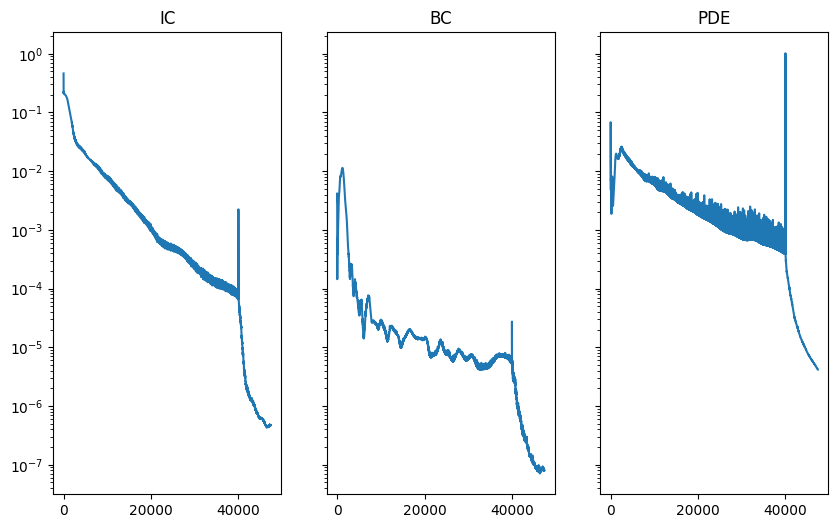

In [8]:
if __name__ == "__main__":
    pinn = PINN()

    # Muon and Adam phase
    for i in range(40000):
        pinn.muonM3.zero_grad()
        pinn.adam.zero_grad()
        loss = pinn.closure()
        pinn.muonM3.step()
        pinn.adam.step()

    # L-BFGS phase
    pinn.lbfgs.step(pinn.closure)

plotLoss(pinn.losses, "./loss_curve_M3(1).png")
torch.save(pinn.net.state_dict(), "./weight_M3(1).pt")

Error_u : 2.709e-03
Error_v : 3.648e-03
Error_h : 1.442e-03


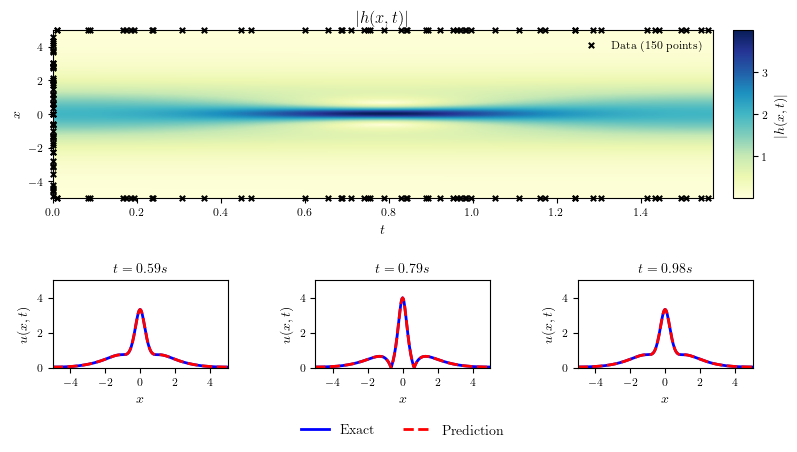

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from mpl_toolkits.axes_grid1 import make_axes_locatable
from scipy.io import loadmat

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

""
pgf_with_latex = {
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": [],
    "font.sans-serif": [],
    "font.monospace": [],
    "axes.labelsize": 10,
    "font.size": 10,
    "legend.fontsize": 8,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
}


def test():
    data = loadmat("./NLS.mat")
    Exact_x = data["x"].flatten()[:, None]
    Exact_t = data["tt"].flatten()[:, None]
    x_mesh, t_mesh = np.meshgrid(Exact_x, Exact_t)
    Exact_xt = np.hstack([x_mesh.flatten()[:, None], t_mesh.flatten()[:, None]])
    Exact_xt = torch.tensor(Exact_xt, dtype=torch.float).to(device)

    Exact = data["uu"]
    Exact_u = np.real(Exact)
    Exact_v = np.imag(Exact)
    Exact_h = np.sqrt(Exact_u ** 2 + Exact_v ** 2)

    u_star = Exact_u.T.flatten()[:, None]
    v_star = Exact_v.T.flatten()[:, None]
    h_star = Exact_h.T.flatten()[:, None]

    with torch.no_grad():
        u_pred, v_pred = pinn.net_uv(Exact_xt)
        h_pred = torch.sqrt(u_pred ** 2 + v_pred ** 2)

    u_pred = u_pred.cpu().numpy()
    v_pred = v_pred.cpu().numpy()
    h_pred = h_pred.cpu().numpy()
    error_u = np.linalg.norm(u_star - u_pred, 2) / np.linalg.norm(u_star, 2)
    error_v = np.linalg.norm(v_star - v_pred, 2) / np.linalg.norm(v_star, 2)
    error_h = np.linalg.norm(h_star - h_pred, 2) / np.linalg.norm(h_star, 2)
    print(f"Error_u : {error_u:.3e}")
    print(f"Error_v : {error_v:.3e}")
    print(f"Error_h : {error_h:.3e}")


plt.rcParams.update(pgf_with_latex)

pinn = PINN()
pinn.net.load_state_dict(torch.load("./weight_M3(1).pt"))


# xt_ic = xt_ic
# xt_lb = xt_lb
# xt_ub = xt_ub

xt_ic = xt_ic.cpu().numpy()
xt_lb = xt_lb.cpu().numpy()
xt_ub = xt_ub.cpu().numpy()

train_data_xt = np.vstack([xt_ic, xt_lb, xt_ub])

data = loadmat("./NLS.mat")
x = data["x"].flatten()
t = data["tt"].flatten()
X, T = np.meshgrid(x, t)
X = X.flatten()[:, None]
T = T.flatten()[:, None]
u_sol = data["uu"].T
h_sol = np.abs(u_sol)


with torch.no_grad():
    xt = torch.tensor(np.hstack([X, T]), dtype=torch.float).to(device)
    uv_pred = pinn.net(xt)
    h_pred = torch.sqrt(uv_pred[:, 0] ** 2 + uv_pred[:, 1] ** 2)

h_pred = h_pred.cpu().numpy().reshape(u_sol.shape).T

test()
############## Plot 1 ###############

fig = plt.figure(figsize=(10, 6))
gs0 = GridSpec(1, 2, figure=fig)
gs0.update(top=1 - 0.06, bottom=0.66, left=0.15, right=0.85, wspace=0)

ax = fig.add_subplot(gs0[0, :])
im = ax.imshow(
    h_pred, cmap="YlGnBu", extent=[0, np.pi / 2, -5, 5], aspect="auto", origin="lower"
)

divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="3%", pad=0.2)

plt.colorbar(im, cax=cax, label="$|h(x,t)|$")
ax.set_xlabel("$t$")
ax.set_ylabel("$x$")

ax.set_title("$|h(x,t)|$")

bc_pt = ax.scatter(
    train_data_xt[:, 1],
    train_data_xt[:, 0],
    s=15,
    c="black",
    marker="x",
    label=f"Data ({len(train_data_xt):d} points)",
    clip_on=False,
)
ax.legend(frameon=False, loc="best")

############## Plot 2 ###############


gs1 = GridSpec(1, 3, figure=fig)
gs1.update(top=0.9, bottom=0, left=0.15, right=0.85, wspace=0.5)

t_idx = [75, 100, 125]
axes = []
for i in range(3):
    ax = fig.add_subplot(gs1[0, i])
    ax.plot(x, h_sol[t_idx[i], :], "b-", linewidth=2, label="Exact")
    ax.plot(x, h_pred[:, t_idx[i]], "r--", linewidth=2, label="Prediction")
    ax.set_xlabel("$x$")
    ax.set_ylabel("$u(x,t)$")
    ax.set_title(f"$t = {t[t_idx[i]]:.2f}s$", fontsize=10)
    ax.axis("square")
    ax.set_xlim([-5, 5])
    ax.set_ylim([0, 5])
    axes.append(ax)
axes[1].legend(
    loc="upper center", bbox_to_anchor=(0.5, -0.50), ncol=2, frameon=False, fontsize=10
)

fig.savefig(
    "./solution_M3(1).png", dpi=500, bbox_inches="tight", pad_inches=0,
)